Code pour faire fonctionner pyspark (ne pas exécuter si pas besoin)

In [1]:
import os, subprocess, shutil
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ.get("PATH", "")
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
print("winutils:", os.path.exists(r"C:\hadoop\bin\winutils.exe"))
print("hadoop.dll:", os.path.exists(r"C:\hadoop\bin\hadoop.dll"))

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot" 
os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + ";" + os.environ.get("PATH", "")
print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("java in PATH:", shutil.which("java"))
print(subprocess.run(["java","-version"], capture_output=True, text=True).stderr)

winutils: True
hadoop.dll: True
JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot
java in PATH: C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot\bin\java.EXE
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Temurin-17.0.18+8 (build 17.0.18+8)
OpenJDK 64-Bit Server VM Temurin-17.0.18+8 (build 17.0.18+8, mixed mode, sharing)



In [2]:
import sys, os
print("Python:", sys.executable)
print("Version:", sys.version)
print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON", "non défini"))
print("PYSPARK_DRIVER_PYTHON:", os.environ.get("PYSPARK_DRIVER_PYTHON", "non défini"))

Python: c:\Users\etien\miniconda3\envs\nf26\python.exe
Version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]
PYSPARK_PYTHON: non défini
PYSPARK_DRIVER_PYTHON: non défini


In [2]:
import sys
# Affiche le chemin de l'exécutable Python utilisé par ce notebook
print(sys.executable)

/Users/maugeear/.venvs/nf26_312/bin/python


Etienne :

In [2]:
import sys, os
from pyspark.sql import SparkSession

if 'spark' in locals():
    spark.stop()

python_path = sys.executable  
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['PYSPARK_DRIVER_PYTHON'] = python_path

spark = (
    SparkSession.builder
    .appName("GHG-Inventory-ETL")
    .config("spark.driver.memory", "16g")  
    .config("spark.executor.memory", "8g")  
    .config("spark.python.worker.exec", python_path)
    .config("spark.sql.ansi.enabled", "false")
    .getOrCreate()
)

print("Python utilisé :", python_path)

Python utilisé : c:\Users\etien\miniconda3\envs\nf26\python.exe


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import pyspark.pandas as ps
from pyspark.sql.functions import *
from datetime import date, timedelta
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import truncnorm

np.random.seed(42) # Fixation de seed pour avoir des résultats reproductibles lors 
# du calcul des distances intra-ville

# Sert à calculer les distances entre les villes
geolocator = Nominatim(user_agent="BGES_app")

## Partie ETL

#### Fonctions de traitement de données

#### Fonctions d'homogénéisation de la langue des fonctions et missions

On homogénéise la langue des missions / fonctions en anglais car 4 sites sur 6 utilisent déjà l'anglais

In [4]:
def clean_langue_fonction(df, site):
    match site:
        case "BERLIN":
            map_fonctions = {
                "Ökonom": "Economist",
                "Führungskraft": "Business Executive",
                "Personalleiter": "HRD",
                "Computeringenieur": "Computer Engineer",
                "Dateningenieur": "Data Engineer",
            }
            df["FONCTION_PERSONNEL"] = df["FONCTION_PERSONNEL"].replace(map_fonctions)
        case "PARIS":
            map_fonctions = {
                "Ingénieur Informaticien": "Computer Engineer",
                "Ingénieur Data": "Data Engineer",
                "Economiste": "Economist",
                "DRH": "HRD",
                "Cadre": "Business Executive",
            }
            df["FONCTION_PERSONNEL"] = df["FONCTION_PERSONNEL"].replace(map_fonctions)


In [5]:
def clean_langue_mission(df, site):
    match site:
        case "BERLIN":
            map_type_mission = {
                "Geschäftstreffen": "Business Meeting",
                "Konferenz": "Conference",
                "Schulung": "Vocational Training",
                "Meeting": "Team Meeting",
                "Entwicklung": "Development",
            }
            df["TYPE_MISSION"] = df["TYPE_MISSION"].replace(map_type_mission)
        case "PARIS":
            map_type_mission = {
                "Conférence": "Conference",
                "Formation": "Vocational Training",
                "Réunion": "Team Meeting",
                "Rencontre entreprises": "Business Meeting",
                "Développement": "Development",
            }
            df["TYPE_MISSION"] = df["TYPE_MISSION"].replace(map_type_mission)


sites = ["PARIS", "LONDON", "BERLIN", "LOSANGELES", "NEWYORK", "SHANGHAI"]

#### Fonction d'homogénéisation des fuseaux horaires

In [6]:
def clean_date(df, site, date_col):
    """
    Convertit la colonne de dates d'un site donné vers UTC+2 (heure de Paris).
    On suppose que le fuseau horaire originel des dates est celui de leur site de provenance. 
    """
    # Mapping site -> fuseau horaire IANA
    site_tz = {
        "PARIS":      "Europe/Paris",
        "BERLIN":     "Europe/Berlin",
        "LONDON":     "Europe/London",
        "NEWYORK":    "America/New_York",
        "LOSANGELES": "America/Los_Angeles",
        "SHANGHAI":   "Asia/Shanghai",
    }

    tz = site_tz[site]

    # S'assurer que la colonne est bien en datetime
    df[date_col] = pd.to_datetime(df[date_col], format="%Y-%m-%d %H:%M:%S")

    # Localiser la date dans le fuseau du site, puis convertir vers Paris (UTC+2 en été)
    df[date_col] = (
        df[date_col]
          .dt.tz_localize(tz, ambiguous=False, nonexistent='shift_forward') # on dit "cette heure est en heure locale du site"
          # les params ambiguous et nonexistent sont utilisés pour les heures du changement d'heure
          .dt.tz_convert("Europe/Paris")  # on la convertit vers Paris
          .dt.tz_localize(None)           # on retire l'info de fuseau horaire
    )

#### Fonctions pour calculer l'age d'un employé

In [7]:
def calcul_age(date_naissance, date_reference=None):
    if date_reference is None:
        date_reference = date.today()
    age = date_reference.year - date_naissance.year
    # Retire 1 an si l'anniversaire n'est pas encore passé
    if (date_reference.month, date_reference.day) < (date_naissance.month, date_naissance.day):
        age -= 1
    return age

def convertir_age_personnel(df_personnel, date_reference=None, timezone="UTC"):

    if date_reference is None:
        date_reference = date.today()
    
    df = df_personnel.copy()
    
    # Conversion au fuseau horaire général
    df["DT_NAISS"] = pd.to_datetime(df["DT_NAISS"], utc=True).dt.tz_convert(timezone)
    
    
    df["AGE"] = df["DT_NAISS"].apply(calcul_age)
    
    # Suppression de DT_NAISS
    df = df.drop(columns=["DT_NAISS"])
    
    return df

#### Fonction pour extraire et traiter les données du personnel

In [8]:
def extract_personnel():
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")

    personnel_dfs = []

    # On charge la liste du personnel de chaque site dans un dataframe
    for site in sites:
        file_path = base_path / f"BDD_BGES_{site}" / f"PERSONNEL_{site}.txt"
        df = pd.read_csv(str(file_path), sep=';')
        clean_langue_fonction(df, site) 
        df['ID_SITE'] = site
        
        personnel_dfs.append(df)

    # On combine les dataframes 
    personnel_df = pd.concat(personnel_dfs)
  
    # On sélectionne uniquement les colonnes nécessaires
    personnel_final_df = personnel_df[['ID_PERSONNEL','FONCTION_PERSONNEL', 'ID_SITE', 'DT_NAISS']]
    personnel_final_df = convertir_age_personnel(personnel_final_df)
    return personnel_final_df

#### Fonction pour imputer les données manquantes des fichiers de matériel

In [9]:
def clean_materiel(df):
    df = df.copy()
    
    # Charger le dictionnaire modèle -> type (une seule fois à la première utilisation)
    if 'modele_to_type' not in globals():
        global modele_to_type
        impact_df = pd.read_csv("./data/BDD_BGES/materiel_informatique_impact.csv")
        modele_to_type = dict(zip(impact_df['Modèle'], impact_df['Type']))
    
    # Nettoyage des espaces blancs
    df['TYPE'] = df['TYPE'].astype(str).str.strip()
    df['MODELE'] = df['MODELE'].astype(str).str.strip()
    
    # Convertir en NaN si vide
    df['TYPE'] = df['TYPE'].replace('', pd.NA)
    df['MODELE'] = df['MODELE'].replace('', pd.NA)
    
    # Remplir les TYPE manquants en utilisant le MODELE
    def get_type_from_modele(row):
        if pd.notna(row['TYPE']):  # Si TYPE existe déjà
            return row['TYPE']
        if pd.notna(row['MODELE']):  # Si MODELE existe, on peut imputer TYPE
            return modele_to_type.get(row['MODELE'], None)
        return None
    
    df['TYPE'] = df.apply(get_type_from_modele, axis=1)
    
    # Remplir les MODELE manquants par "modèle par défaut"
    df['MODELE'] = df['MODELE'].fillna('modèle par défaut')
    
    # Remplir les TYPE restants manquants par une valeur par défaut 
    df['TYPE'] = df['TYPE'].fillna('Matériel Informatique')
    
    return df

Fonction pour calculer les impacts du matériel

In [10]:
# On charge le fichier qui contient l'impact carbone du matériel informatique. 
import unicodedata

IMPACT_MAT_INFO_DF = pd.read_csv("./data/BDD_BGES/materiel_informatique_impact.csv")

#Fonction pour retirer les accents et convertir en majuscules les noms de colonne (pour jointures ultérieures)
def remove_accents_and_uppercase(name):
    #Normaliser et retirer les accents
    normalized = unicodedata.normalize('NFD', name)
    without_accents = ''.join(char for char in normalized if unicodedata.category(char) != 'Mn')
    return without_accents.upper()

# Convertir tous les noms de colonnes en majuscules sans accents pour pouvoir faire les jointures
IMPACT_MAT_INFO_DF.columns = [remove_accents_and_uppercase(c) for c in IMPACT_MAT_INFO_DF.columns]
IMPACT_MAT_INFO_DF['IMPACT'] = IMPACT_MAT_INFO_DF['IMPACT'].fillna(0)

# Fonction pour calculer et ajouter la colonne impact
def add_impact_materiel(mat_df, impact_df = IMPACT_MAT_INFO_DF):
    merged = mat_df.merge(
        impact_df[['TYPE', 'MODELE', 'IMPACT']],
        on=['TYPE', 'MODELE'],
        how='left'
    )
    mat_df['IMPACT'] = merged['IMPACT'].fillna(0).astype(float) / 1000

Clarification du transport "transports en communs" : 

Sur le site labos1.5, on a plusieurs types de transports en commun, dont deux qui ne sont pas pris en compte dans la liste donnée dans le sujet (bus et bateau). Cependant, quand on regarde dans la liste des missions, on constate que les missions labellisées transport en commun ont toutes la même ville d'arrivée et de départ, cf exécuter le code suivant : 

```python
missions_df[(missions_df["TRANSPORT"] == "Transports en commun") & (missions_df["VILLE_DEPART"] != missions_df["VILLE_DESTINATION"])]
```

On considère donc que les trajets en transport peuvent être représentés par des trajets en bus. Sur le site de labo1.5 on trouve : 

Spécificité des déplacements en bus :
Nous faisons l’hypothèse que les trajets en bus inter-urbains seront majoritaires en terme de distances parcourues lors d’une mission, comparativement aux trajets en bus urbains. Les trajets inter-urbains étant moins émetteurs que les trajets urbains, nous prenons le facteur d’émission le moins élevé parmi les 3 facteurs disponibles dans la Base Carbone: c’est celui des bus dans des agglomérations de plus de 250 000 habitants.

Ce facteur sera donc utilisé pour les missions utilisant le type de transport "transports en commun".

Fonction de calcul des distances entre 2 villes avec geopy

In [11]:
# Dictionnaire des coefficients en fonction du mode de transport
COEFFS_DISTANCE = {
    "Train" : 1.2,
    "Taxi" : 1.2,
    "Transports en commun" : 1.5
}

# Dictionnaire de coordonnées pour éviter les appels répétés et la limitation API GeoPy
CITY_COORDS = {
    # Sites principaux
    ("Paris", "France"): (48.8566, 2.3522),
    ("Berlin", "Germany"): (52.5200, 13.4050),
    ("Berlin", "Allemagne"): (52.5200, 13.4050),
    ("London", "England"): (51.5074, -0.1278),
    ("New York", "USA"): (40.7128, -74.0060),
    ("New-York", "USA"): (40.7128, -74.0060),
    ("Los Angeles", "USA"): (34.0522, -118.2437),
    ("Shanghai", "China"): (31.2304, 121.4737),
    ("Marseille", "France"): (43.2965, 5.3698),
    ("Compiègne", "France"): (49.4144, 2.8259),
    ("Stockholm", "Sweden"): (59.3293, 18.0686),
    ("Stockholm", "Suède"): (59.3293, 18.0686),
    ("Helsinki", "Finland"): (60.1695, 24.9354),
    ("Helsinki", "Finlande"): (60.1695, 24.9354),
    ("Osaka", "Japan"): (34.6937, 135.5023),
    ("Tokyo", "Japan"): (35.6762, 139.6503),
    ("Melbourne", "Australia"): (-37.8136, 144.9631),
    ("Sydney", "Australia"): (-33.8688, 151.2093),
    ("Sidney", "Australia"): (-33.8688, 151.2093),
    ("Wellington", "New Zealand"): (-41.2865, 174.7762),
    ("Montreal", "Canada"): (45.5017, -73.5673),
    ("Vancouver", "Canada"): (49.2827, -123.1207),
    ("Washington", "USA"): (38.9072, -77.0369),
    ("Buenos Aires", "Argentina"): (-34.6037, -58.3816),
    ("Bogota", "Colombia"): (4.7110, -74.0721),
    ("Rio de Janeiro", "Brazil"): (-22.9068, -43.1729),
    ("Rabat", "Morocco"): (34.0209, -6.8416),
    ("Rabat", "Maroc"): (34.0209, -6.8416),
    ("Dubaï", "Emirats"): (25.2048, 55.2708),
    ("Mexico", "Mexico"): (19.4326, -99.1332),
    ("Tunis", "Tunisia"): (36.8065, 10.1686),
    ("Tunis", "Tunisie"): (36.8065, 10.1686),
    ("Sao Paulo", "Brazil"): (-23.5505, -46.6333),
    ("Stockholm", "Sweden"): (59.3293, 18.0686),
    ("Stockholm", "Suede"): (59.3293, 18.0686),
    ("Alger", "Algeria"): (36.7538, 3.0588),
    ("Auckland", "New Zealand"): (-37.0882, 174.8860),
    ("Bordeaux", "France"): (44.8378, -0.5792),
    ("Pekin", "China"): (39.9042, 116.4074),
    ("Beijing", "China"): (39.9042, 116.4074),
    ("Lille", "France"): (50.6292, 3.0573),
    ("Oslo", "Norvège"): (59.9139, 10.7522),
    ("Oslo", "Norway"): (59.9139, 10.7522),
    ("Lima", "Peru"): (-12.0464, -77.0428)
}

def get_distance_between_cities(ville_depart, pays_depart, ville_destination, pays_destination):
    try:      
        # Si c'est un trajet intra-ville, on estime la distance de manière aléatoire
        # avec une loi normale et des valeurs raisonnables
        if (ville_depart.lower() == ville_destination.lower() and pays_depart.lower() == pays_destination.lower()):
            moyenne = 8      
            ecart_type = 3   

            # Générer une distance estimée avec loi normale
            distance = np.random.normal(moyenne, ecart_type)

            # Éviter les distances négatives
            distance_km = 0 if distance < 0 else distance
            return distance_km
        
        # Si trajets entre 2 villes différentes : chercher dans le dictionnaire d'abord
        coords_depart = CITY_COORDS.get((ville_depart, pays_depart))
        coords_dest = CITY_COORDS.get((ville_destination, pays_destination))
        
        # Si ville de départ non trouvée, appeler Nominatim
        if not coords_depart:
            print("ville depart non présente: ", ville_depart)
            print("pays depart non présent: ", pays_depart)
            location_depart = geolocator.geocode(f"{ville_depart}, {pays_depart}", timeout=10)
            if location_depart:
                coords_depart = (location_depart.latitude, location_depart.longitude)
        
        # Si ville de destination non trouvée, appeler Nominatim
        if not coords_dest:
            print("ville arrivee non présente: ", ville_destination)
            print("pays arrivee non présent: ", pays_destination)
            location_destination = geolocator.geocode(f"{ville_destination}, {pays_destination}", timeout=10)
            if location_destination:
                coords_dest = (location_destination.latitude, location_destination.longitude)
        
        # Si les deux coordonnées ont été trouvées, calculer la distance
        if coords_depart and coords_dest:
            distance_km = geodesic(coords_depart, coords_dest).kilometers
            return distance_km
        else:
            return None
            
    except Exception as e:
        print(f"Erreur lors du calcul: {e}")
        return None

Fonction permettant de calculer les emissions des missions

In [12]:
def get_emission(distance, transport, ar, pays_depart, pays_destination):
        #Chargement des fichiers permettant de récupérer les facteurs d'émission
        base_path = Path("data/facteurs_emission")
        fe_transports_en_commun_df = pd.read_csv(base_path / "fe_transports_en_commun.tsv", sep='\t')
        fe_vehicules_df = pd.read_csv(base_path / "fe_vehicules.tsv", sep='\t')
        fe_transports_en_commun_df.head(100)


        #Multiplicateur si le trajet est un aller-retour
        multAr = 2 if ar == "oui" else 1

        #Modification de la distance en fonction du moyen de transport
        if(transport == "Avion"):
            distance += 95
        else : 
            distance *= COEFFS_DISTANCE.get(transport)
        
        #Calcul du facteur et de l'emission totale en fonction du moyen de transport
        #On divise par 1000 à chaque fois pour renvoyer la quantité directement en tCO2e
        match transport:
            case "Avion":
                if distance < 1000:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Court courrier (< 1000 km)"]["total"].iloc[0]
                elif distance < 3500:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Moyen courrier (< 1001 - 3500km)"]["total"].iloc[0]
                else:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Long courrier (> 3500 km)"]["total"].iloc[0]
                
                return distance*facteur*multAr/1000

            
            case "Train":
                if(pays_depart == "France"):
                    if(pays_destination == "France"):
                        if distance > 200 :
                            facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "TGV > 200 km"]["total"].iloc[0]
                        else:
                            facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train < 200 km"]["total"].iloc[0]
                    else:
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train mixte France et international"]["total"].iloc[0]
                else:
                    if(pays_destination == "France"):
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train mixte France et international"]["total"].iloc[0]
                    else:
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train international"]["total"].iloc[0]
                
                return distance*facteur*multAr/1000
            
            case "Taxi":
                facteur = fe_vehicules_df[fe_vehicules_df["subsubcategory"] == "Motorisation inconnue"]["total"].iloc[0]
                #On calcule aussi les émissions pour le trajet aller (on condisère 2 personnes à bord)
                #et retour (on considère le chauffeur seul à bord)
                em = (distance * (1 + 1/2) * facteur) 
                return multAr*em/1000
            
            case "Transports en commun":
                facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Bus > 250 000 habitants"]["total"].iloc[0]
                return distance*facteur*multAr/1000

#### Fonction pour extraire et traiter les données de matériel

In [13]:
def extract_materiel(date):
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")
    
    day_str = date.strftime("%Y%m%d")
    materiel_day_dfs = []
    
    # Boucle sur chaque site
    for site in sites:
        file_path = base_path / f"BDD_BGES_{site}/BDD_BGES_{site}_INFORMATIQUE/MATERIEL_INFORMATIQUE_{day_str}.txt"
        
        # Vérifier si le fichier existe avant de le lire
        if file_path.exists():
            df = pd.read_csv(str(file_path), sep=';')
            clean_date(df, site, "DATE_ACHAT")
            df = clean_materiel(df)  # Nettoyer et imputer données manquantes
            df['ID_DATE'] = df['DATE_ACHAT'].dt.date
            add_impact_materiel(df)
            materiel_day_dfs.append(df)
            
    # Si des fichiers ont été trouvés pour ce jour
    if materiel_day_dfs:
        return pd.concat(materiel_day_dfs, ignore_index=True)
    else:
        print(f"Aucun fichier de matériel trouvé pour {day_str}.")
        return None


#### Fonction pour extraire et traiter les données des missions

In [14]:
# Même logique que la fonction d'extraction du matériel
def extract_missions(date):
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")
    
    day_str = date.strftime("%Y%m%d")
    missions_day_dfs = []
    
    for site in sites:
        file_path = base_path / f"BDD_BGES_{site}/BDD_BGES_{site}_MISSION/MISSION_{day_str}.txt"
        
        if file_path.exists():
            df = pd.read_csv(str(file_path), sep=';')
            clean_langue_mission(df, site)
            clean_date(df, site, "DATE_MISSION")
            df['ID_SITE'] = site
            df['ID_DATE'] = df['DATE_MISSION'].dt.date # Pour jointure
            # Calcul de la distance entre les villes depart et destination
            df['DISTANCE_KM'] = df.apply(
                lambda row: get_distance_between_cities(
                    row['VILLE_DEPART'],
                    row['PAYS_DEPART'],
                    row['VILLE_DESTINATION'],
                    row['PAYS_DESTINATION'],
                ),
                axis=1
            )
            # Calcul de l'emission des missions
            df['EMISSION'] = df.apply(
                lambda row: get_emission(
                    row['DISTANCE_KM'],
                    row['TRANSPORT'],
                    row['ALLER_RETOUR'],
                    row['PAYS_DEPART'],
                    row['PAYS_DESTINATION']
                ),
                axis=1
            )
            missions_day_dfs.append(df)
            
    if missions_day_dfs:
        return pd.concat(missions_day_dfs, ignore_index=True)
    else:
        print(f"Aucun fichier de missions trouvé pour {day_str}.")
        return None

#### Extraction et traitement des données brutes

#### Récupération de la plage de date comprenant toutes les données

In [15]:
def get_date_range_from_bges(root_path="data/BDD_BGES"):
    root = Path(root_path)
    
    # Chercher tous les fichiers de missions et matériel
    mission_files = list(root.rglob("MISSION_*.txt"))
    materiel_files = list(root.rglob("MATERIEL_INFORMATIQUE_*.txt"))
    
    all_files = mission_files + materiel_files
    
    if not all_files:
        print(f"Aucun fichier trouvé dans {root_path}")
        return None, None
    
    # Extraire les dates des noms de fichiers
    dates = []
    
    for fichier in all_files:
        stem = fichier.stem  # ex: 'MISSION_20260429' ou 'MATERIEL_INFORMATIQUE_20260429'
        # Extraire la partie YYYYMMDD (8 derniers caractères du stem)
        candidate = stem.split('_')[-1]
        
        if len(candidate) == 8 and candidate.isdigit():
            try:
                date_obj = pd.to_datetime(candidate, format="%Y%m%d")
                dates.append(date_obj)
            except:
                print(f"Impossible de parser: {fichier.name}")
    
    if not dates:
        print("Aucune date valide trouvée dans les noms de fichiers.")
        return None, None
    
    dates = pd.to_datetime(dates)
    earliest = dates.min().date()
    latest = dates.max().date()
    
    return earliest, latest

earliest_date, latest_date = get_date_range_from_bges()
print(f"Date la ancienne : {earliest_date}")
print(f"Date la plus récente : {latest_date}")

Date la ancienne : 2026-04-29
Date la plus récente : 2026-11-14


In [16]:
start_date = date(2026, 4, 29)
end_date = date(2026, 11, 14) 

#### Extraction et traitement des données depuis les fichiers sources en utilisant les fonctions définies précédemment.

In [17]:
# Données du personnel
personnel_df = extract_personnel()
personnel_df.head()

,ID_PERSONNEL,FONCTION_PERSONNEL,ID_SITE,AGE
0,KeyPers_Paris_1230000,Business Executive,PARIS,94
1,KeyPers_Paris_1230001,HRD,PARIS,63
2,KeyPers_Paris_1230002,Data Engineer,PARIS,47
3,KeyPers_Paris_1230003,Computer Engineer,PARIS,81
4,KeyPers_Paris_1230004,Computer Engineer,PARIS,45


In [18]:
# Pour les données datées, on boucle sur toutes les dates, et on extrait et transforme les données 
# jour par jour. On concatène les données transformées après traitement

all_mat_dfs = []
all_missions_dfs = []


# Boucle sur chaque jour
for cur_date in pd.date_range(start_date, end_date):
    # Données du matériel
    mat_df = extract_materiel(cur_date)
    # Données des missions
    missions_df = extract_missions(cur_date)

    if mat_df is not None:
        all_mat_dfs.append(mat_df)
    if missions_df is not None:
        all_missions_dfs.append(missions_df)

# Concaténation des données de tous les jours traités dans la boucle
mat_df = pd.concat(all_mat_dfs, ignore_index=True) if all_mat_dfs else None
missions_df = pd.concat(all_missions_dfs, ignore_index=True) if all_missions_dfs else None

In [19]:
mat_df.head()

,ID_MATERIELINFO,ID_PERSONNEL,NOM_PERSONNEL,PRENOM_PERSONNEL,DATE_ACHAT,TYPE,MODELE,ID_DATE,IMPACT
0,Paris_MATERIEL_INFO_202604290,KeyPers_Paris_1232362,Name2362,FistName2362,2026-04-29 08:17:31,PC fixe sans ecran,Z,2026-04-29,0.409
1,Paris_MATERIEL_INFO_202604291,KeyPers_Paris_1232165,Name2165,FistName2165,2026-04-29 09:42:55,imprimante,Laser A3 (>100kg),2026-04-29,1.800
2,Paris_MATERIEL_INFO_202604292,KeyPers_Paris_1231951,Name1951,FistName1951,2026-04-29 13:58:12,PC fixe sans ecran,Precision tower 3xxx,2026-04-29,0.285
3,Paris_MATERIEL_INFO_202604293,KeyPers_Paris_1230614,Name614,FistName614,2026-04-29 13:19:31,Telephone IP,modèle par défaut,2026-04-29,0.017
4,Paris_MATERIEL_INFO_202604294,KeyPers_Paris_1232952,Name2952,FistName2952,2026-04-29 13:55:41,GPU puissant,modèle par défaut,2026-04-29,0.060


In [20]:
missions_df.head()

,ID_MISSION,ID_PERSONNEL,NOM_PERSONNEL,PRENOM_PERSONNEL,DATE_MISSION,TYPE_MISSION,VILLE_DEPART,PAYS_DEPART,VILLE_DESTINATION,PAYS_DESTINATION,TRANSPORT,ALLER_RETOUR,ID_SITE,ID_DATE,DISTANCE_KM,EMISSION
0,Paris_202604290,KeyPers_Paris_1233578,Name3578,FistName3578,2026-04-29 15:01:12,Business Meeting,Paris,France,New-York,USA,Avion,oui,PARIS,2026-04-29,5852.935292,1.808172
1,Paris_202604291,KeyPers_Paris_1234968,Name4968,FistName4968,2026-04-29 18:41:44,Development,Paris,France,London,England,Avion,oui,PARIS,2026-04-29,343.923120,0.227011
2,Paris_202604292,KeyPers_Paris_1233110,Name3110,FistName3110,2026-04-29 09:13:25,Business Meeting,Paris,France,Washington,USA,Avion,oui,PARIS,2026-04-29,6180.838912,1.907855
3,Paris_202604293,KeyPers_Paris_1230093,Name93,FistName93,2026-04-29 13:04:44,Conference,Paris,France,Berlin,Allemagne,Avion,oui,PARIS,2026-04-29,879.699316,0.504114
4,Paris_202604294,KeyPers_Paris_1234582,Name4582,FistName4582,2026-04-29 15:34:56,Development,Paris,France,Montreal,Canada,Avion,oui,PARIS,2026-04-29,5521.119614,1.707300


#### Passage des données nettoyées au format Pyspark SQL Dataframe pour préparer leur chargement dans les tables finales du modèle étoile. 

In [21]:
sdf_materiel = spark.createDataFrame(mat_df)
sdf_personnel = spark.createDataFrame(personnel_df)
sdf_mission = spark.createDataFrame(missions_df)

#### Création des tables de dimension

In [22]:
dim_materiel = (
    sdf_materiel
    .select("ID_MATERIELINFO", "TYPE", "MODELE", "IMPACT")
    .withColumnRenamed("ID_MATERIELINFO", "ID_MATERIEL")
)

In [97]:
dim_materiel.show(5)

+--------------------+------------------+--------------------+------+
|         ID_MATERIEL|              TYPE|              MODELE|IMPACT|
+--------------------+------------------+--------------------+------+
|Paris_MATERIEL_IN...|PC fixe sans ecran|                   Z| 0.409|
|Paris_MATERIEL_IN...|        imprimante|   Laser A3 (>100kg)|   1.8|
|Paris_MATERIEL_IN...|PC fixe sans ecran|Precision tower 3xxx| 0.285|
|Paris_MATERIEL_IN...|      Telephone IP|   modèle par défaut| 0.017|
|Paris_MATERIEL_IN...|      GPU puissant|   modèle par défaut|  0.06|
+--------------------+------------------+--------------------+------+
only showing top 5 rows


In [23]:
data = [("BERLIN",), ("LONDON",), ("LOSANGELES",), ("NEWYORK",), ("PARIS",), ("SHANGHAI",)]
dim_site = spark.createDataFrame(data).toDF("ID_SITE")

In [21]:
dim_site.show(6)

+----------+
|   ID_SITE|
+----------+
|    BERLIN|
|    LONDON|
|LOSANGELES|
|   NEWYORK|
|     PARIS|
|  SHANGHAI|
+----------+



In [24]:
# Convertir toutes les dates au même format (datetime)
dates_missions = set(pd.to_datetime(missions_df['ID_DATE']))
dates_materiel = set(pd.to_datetime(mat_df['ID_DATE']))

# Combiner et trier
all_dates = sorted(dates_missions | dates_materiel)

# Créer la table de dimension
dim_date_data = [(d.date(),) for d in all_dates]
dim_date = spark.createDataFrame(dim_date_data, "ID_DATE date")

In [23]:
dim_date.show(5)

+----------+
|   ID_DATE|
+----------+
|2026-04-28|
|2026-04-29|
|2026-04-30|
|2026-05-01|
|2026-05-02|
+----------+
only showing top 5 rows


In [25]:
dim_personnel = sdf_personnel

In [26]:
dim_personnel.show(5)

+--------------------+------------------+-------+---+
|        ID_PERSONNEL|FONCTION_PERSONNEL|ID_SITE|AGE|
+--------------------+------------------+-------+---+
|KeyPers_Paris_123...|Business Executive|  PARIS| 94|
|KeyPers_Paris_123...|               HRD|  PARIS| 63|
|KeyPers_Paris_123...|     Data Engineer|  PARIS| 47|
|KeyPers_Paris_123...| Computer Engineer|  PARIS| 81|
|KeyPers_Paris_123...| Computer Engineer|  PARIS| 45|
+--------------------+------------------+-------+---+
only showing top 5 rows


In [26]:
dim_mission = (
    sdf_mission
    .select(
        "ID_MISSION",
        "TYPE_MISSION",
        "VILLE_DEPART",
        "PAYS_DEPART",
        "VILLE_DESTINATION",
        "PAYS_DESTINATION",
        "TRANSPORT",
        "ALLER_RETOUR",
        "EMISSION"
    )
)

In [72]:
dim_mission.show(5)

+---------------+----------------+------------+-----------+-----------------+----------------+---------+------------+-------------------+
|     ID_MISSION|    TYPE_MISSION|VILLE_DEPART|PAYS_DEPART|VILLE_DESTINATION|PAYS_DESTINATION|TRANSPORT|ALLER_RETOUR|           EMISSION|
+---------------+----------------+------------+-----------+-----------------+----------------+---------+------------+-------------------+
|Paris_202604290|Business Meeting|       Paris|     France|         New-York|             USA|    Avion|         oui| 1.8081723286970963|
|Paris_202604291|     Development|       Paris|     France|           London|         England|    Avion|         oui|0.22701103771105963|
|Paris_202604292|Business Meeting|       Paris|     France|       Washington|             USA|    Avion|         oui| 1.9078550293862238|
|Paris_202604293|      Conference|       Paris|     France|           Berlin|       Allemagne|    Avion|         oui| 0.5041144863019249|
|Paris_202604294|     Development|

#### Création tables de faits

In [27]:
fait_materiel = (
    sdf_materiel
    .join(dim_date, "ID_DATE", "inner")
    .join(sdf_personnel, "ID_PERSONNEL", "inner")
    .join(dim_site, "ID_SITE", "inner")
    .select(col("ID_MATERIELINFO").alias("ID_MATERIEL"), "ID_PERSONNEL", "ID_SITE", col("ID_DATE").alias("ID_DATE_ACHAT"))
)

In [74]:
fait_materiel.show(5)

+--------------------+--------------------+-------+-------------+
|         ID_MATERIEL|        ID_PERSONNEL|ID_SITE|ID_DATE_ACHAT|
+--------------------+--------------------+-------+-------------+
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-23|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-23|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-23|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-22|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-22|
+--------------------+--------------------+-------+-------------+
only showing top 5 rows


In [28]:
fait_mission = (
    sdf_mission
    .join(dim_date, "ID_DATE", "inner")
    .join(sdf_personnel, "ID_PERSONNEL", "inner")
    .join(dim_site, "ID_SITE", "inner")
    .select("ID_MISSION", "ID_PERSONNEL", sdf_mission.ID_SITE, col("ID_DATE").alias("ID_DATE_MISSION"))
)

In [31]:
fait_mission.show(5)

+----------------+--------------------+-------+---------------+
|      ID_MISSION|        ID_PERSONNEL|ID_SITE|ID_DATE_MISSION|
+----------------+--------------------+-------+---------------+
|BERLIN_202605100|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605101|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605102|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605103|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605104|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
+----------------+--------------------+-------+---------------+
only showing top 5 rows


## Réponses aux questions

1. Combien de cadres travaillent sur le site de Paris ?

In [76]:
nb_cadres_paris = (
    dim_personnel
    .filter(col("ID_SITE") == "PARIS")
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .count()
)

print(f"{nb_cadres_paris} cadres travaillent sur le site de Paris")

929 cadres travaillent sur le site de Paris


2. Combien d’ingénieurs Data travaillent sur les sites aux États-Unis ?

In [33]:
nb_inge_data_us = (
    dim_personnel
    .filter((col("ID_SITE") == "LOSANGELES") |  (col("ID_SITE") == "NEWYORK"))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .count()
)

print(f"{nb_inge_data_us} ingénieurs Data travaillent sur les sites aux États-Unis")

2197 ingénieurs Data travaillent sur les sites aux États-Unis


3. Combien d’ingénieurs informaticiens travaillent dans l’organisation (tous sites compris) ?

In [34]:
nb_inge_info = (
    dim_personnel
    .filter(col("FONCTION_PERSONNEL") == "Computer Engineer")
    .count()
)

print(f"{nb_inge_info} ingénieurs informaticiens travaillent dans l'organisation (tous sites compris)")

7696 ingénieurs informaticiens travaillent dans l'organisation (tous sites compris)


4. Combien de PC fixes ont été achetés par l’organisation entre juin et septembre 2026 ?

In [77]:
nb_pc_fixes = (
    dim_materiel
    .filter((col("TYPE") == "PC fixe sans ecran") | (col("TYPE") == "PC fixe tout-en-un"))
    .join(fait_materiel, "ID_MATERIEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 6, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 9, 30)))
    .count()
)

print(f"{nb_pc_fixes} PC fixes ont été achetés entre juin et septembre 2026")

1970 PC fixes ont été achetés entre juin et septembre 2026


5. Quelle a été l’impact carbone des PC fixes sans ecran entre mai et octobre 2026 ?

In [79]:
dim_materiel.show(5)

+--------------------+------------------+--------------------+------+
|         ID_MATERIEL|              TYPE|              MODELE|IMPACT|
+--------------------+------------------+--------------------+------+
|Paris_MATERIEL_IN...|PC fixe sans ecran|                   Z| 0.409|
|Paris_MATERIEL_IN...|        imprimante|   Laser A3 (>100kg)|   1.8|
|Paris_MATERIEL_IN...|PC fixe sans ecran|Precision tower 3xxx| 0.285|
|Paris_MATERIEL_IN...|      Telephone IP|   modèle par défaut| 0.017|
|Paris_MATERIEL_IN...|      GPU puissant|   modèle par défaut|  0.06|
+--------------------+------------------+--------------------+------+
only showing top 5 rows


In [105]:
impact_pc_fixes = (
    dim_materiel
    .filter(col("TYPE") == "PC fixe sans ecran")
    .join(fait_materiel, "ID_MATERIEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 5, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 10, 31)))
    .agg(sum(col("IMPACT")))
    .first()[0]
)

print(f"L'impact des PC fixes sans ecran a été de {impact_pc_fixes:.3f} tCO2e entre mai et octobre 2026")

L'impact des PC fixes sans ecran a été de 649.265 tCO2e entre mai et octobre 2026


6. Quelle a été l’impact carbone des PC portables achetés par les ingénieurs Data entre mai et octobre 2026 sur les sites de Londres et New-York ?

In [ ]:
impact_pc_portables = (
    dim_personnel
    .filter((col("ID_SITE") == "LONDON") |  (col("ID_SITE") == "NEWYORK"))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .join(fait_materiel, "ID_PERSONNEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 5, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 10, 31)))
    .join(dim_materiel, "ID_MATERIEL")
    .filter(col("TYPE") == "PC portable")
    .agg(sum(col("IMPACT")))
    .first()[0]
)

print(f"L'impact des PC portables achetés entre mai et octobre 2026 par les ingénieurs Data sur les sites de Londres et New-York a été de {impact_pc_portables:.3f} tCO2e")

L'impact des PC portables achetés entre mai et octobre 2026 par les ingénieurs Data sur les sites de Londres et New-York a été de 75.40199999999999 tCO2e


7. Quelle a été l’impact carbone des Ecrans achetés par les cadres entre juillet et septembre 2026 sur tous les sites de l’organisation ?

In [ ]:
impact_ecrans = (
    dim_personnel
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .join(fait_materiel, "ID_PERSONNEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 7, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 9, 30)))
    .join(dim_materiel, "ID_MATERIEL")
    .filter(col("TYPE") == "Ecran")
    .agg(sum(col("IMPACT")))
    .first()[0]
)

print(f"L'impact des écrans achetés entre juillet et septembre 2026 par les cadres sur tous les sites a été de {impact_ecrans:.3f} tCO2e")

L'impact des écrans achetés entre juillet et septembre 2026 par les cadres sur tous les sites a été de 16.07 tCO2e


8. Quelle a été l’impact carbone des missions sur les sites Européens entre mai et octobre 2026 ?

In [107]:
# On isole les missions concernées
emission = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "LONDON") | (col("ID_SITE") == "BERLIN"))
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 10, 31)))
    .agg(sum(col("EMISSION")))
    .first()[0]
)

print(f"L’impact carbone des missions sur les sites Européens entre mai et octobre 2026 est de {emission:.3f} tCO2e.")

L’impact carbone des missions sur les sites Européens entre mai et octobre 2026 est de 25704.517 tCO2e.


9. Quels ont été les 5 jours les plus impactents concernant les missions en avion pour les sites Européens de l’organisation ?

In [109]:
missions_avion = (
    dim_mission
    .filter(col("TRANSPORT") == "Avion")
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "LONDON") | (col("ID_SITE") == "BERLIN"))
    .groupBy(col('ID_DATE_MISSION'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .orderBy(col("EMISSION").desc())
    .select("ID_DATE_MISSION", "EMISSION")
)

missions_avion.show(5)

+---------------+------------------+
|ID_DATE_MISSION|          EMISSION|
+---------------+------------------+
|     2026-08-05|235.70037095698825|
|     2026-05-15|217.38835118032594|
|     2026-05-30| 217.3208791505937|
|     2026-07-22| 215.1760761448485|
|     2026-10-04| 210.8528605299539|
+---------------+------------------+
only showing top 5 rows


10. Quel a été le secteur d’activité qui a eu le plus d’impact concernant les missions et le matériel informatique sur l’ensemble des
sites de l’organisation ?

Emission des missions en fonction du secteur d'activité : 

In [111]:
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .groupBy(col('FONCTION_PERSONNEL'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("FONCTION_PERSONNEL", "EMISSION")
)

missions.show()

+------------------+------------------+
|FONCTION_PERSONNEL|          EMISSION|
+------------------+------------------+
| Computer Engineer|20496.580005149146|
|               HRD|1011.5021668769651|
|Business Executive|10112.786915370476|
|         Economist|3288.2280360933732|
|     Data Engineer|20793.593889402968|
+------------------+------------------+



Calcul des impacts du matériel en fonction du secteur d'activité :

In [112]:
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .join(dim_personnel, "ID_PERSONNEL")
    .groupBy(col('FONCTION_PERSONNEL'))
    .agg(sum(col("IMPACT")).alias("EMISSION_MATERIEL"))   
    .select("FONCTION_PERSONNEL", "EMISSION_MATERIEL")
)

mat_inf.show()

+------------------+------------------+
|FONCTION_PERSONNEL| EMISSION_MATERIEL|
+------------------+------------------+
| Computer Engineer|1126.9679999999876|
|               HRD|            57.009|
|Business Executive| 530.9029999999985|
|         Economist|193.01400000000018|
|     Data Engineer|1041.5509999999865|
+------------------+------------------+



Jointure des impacts du matériel et des missions pour avoir l'impact total en fonction du secteur d'activité et affichage par impact décroissant :

In [114]:
total = (
    missions
    .join(mat_inf, "FONCTION_PERSONNEL")
    .withColumn("TOT_IMPACT", col("EMISSION") + col("EMISSION_MATERIEL"))
    .select("FONCTION_PERSONNEL", "TOT_IMPACT")
    .orderBy(col("TOT_IMPACT").desc())
)

total.show()

+------------------+------------------+
|FONCTION_PERSONNEL|        TOT_IMPACT|
+------------------+------------------+
|     Data Engineer|21835.144889402913|
| Computer Engineer|21623.548005149012|
|Business Executive|10643.689915370445|
|         Economist| 3481.242036093386|
|               HRD|1068.5111668769644|
+------------------+------------------+



11. Quel site a eu le plus d’impact concernant les missions et le matériel informatique sur l’ensemble des sites de l’organisation ?

Impact des missions : 

In [ ]:
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .groupBy(col('ID_SITE'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("ID_SITE", "EMISSION")
)

missions.show()

+----------+------------------+
|   ID_SITE|          EMISSION|
+----------+------------------+
|LOSANGELES|11609.583650527527|
|   NEWYORK| 9671.107107601925|
|    BERLIN| 9642.460005699073|
|    LONDON| 9395.465993665244|
|     PARIS| 8770.837989349237|
|  SHANGHAI| 6613.236266049656|
+----------+------------------+



Impact du materiel : 

In [ ]:
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .groupBy(col('ID_SITE'))
    .agg(sum(col("IMPACT")).alias("EMISSION_MATERIEL"))   
    .select("ID_SITE", "EMISSION_MATERIEL")
)

mat_inf.show()

+----------+------------------+
|   ID_SITE| EMISSION_MATERIEL|
+----------+------------------+
|LOSANGELES| 566.9359999999984|
|     PARIS|  551.229999999999|
|   NEWYORK| 545.8459999999983|
|    LONDON| 516.7249999999995|
|  SHANGHAI| 498.3459999999996|
|    BERLIN|270.36200000000036|
+----------+------------------+



Jointure des impacts du matériel et des missions pour avoir l'impact total en fonction du site et affichage par impact décroissant :

In [118]:
total = (
    missions
    .join(mat_inf, "ID_SITE")
    .withColumn("TOT_IMPACT", col("EMISSION") + col("EMISSION_MATERIEL"))
    .select("ID_SITE", "TOT_IMPACT")
    .orderBy(col("TOT_IMPACT").desc())
)

total.show()

+----------+------------------+
|   ID_SITE|        TOT_IMPACT|
+----------+------------------+
|LOSANGELES|12176.519650527525|
|   NEWYORK|10216.953107601923|
|    BERLIN| 9912.822005699074|
|    LONDON| 9912.190993665243|
|     PARIS| 9322.067989349236|
|  SHANGHAI| 7111.582266049655|
+----------+------------------+



Question 12 : Quel a été l’impact carbone des missions reliant chaque site (la ville de départ est un site de l’organisation et la ville d’arrivée
également) durant le mois de septembre 2026 ?

In [119]:
sites_missions = ["Los Angeles", "New-York", "Paris", "London", "Shanghai", "Berlin"]

impact_missions_inter_sites = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter(col("VILLE_DEPART").isin(sites_missions) & col("VILLE_DESTINATION").isin(sites_missions))
    .filter((col("ID_DATE_MISSION") >= date(2026, 9, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .agg(sum(col("EMISSION")))
    .first()[0]
)

print(f"L’impact carbone des missions reliant chaque site durant le mois de septembre 2026 est de {impact_missions_inter_sites:.3f} tCO2e")

L’impact carbone des missions reliant chaque site durant le mois de septembre 2026 est de 944.770 tCO2e


Question 13 : Quel a été l’impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles ?

In [120]:
impact_seminaires_la = (
    dim_mission
    .filter((col("TYPE_MISSION")) == "Conference") 
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "LOSANGELES"))
    .filter((col("ID_DATE_MISSION") >= date(2026, 7, 1)) & (col("ID_DATE_MISSION") <= date(2026, 7, 31)))
    .agg(sum(col("EMISSION")))
    .first()[0]
)

print(f"L'impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles est de {impact_seminaires_la:.3f} tCO2e")

L'impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles est de 341.476 tCO2e


Question 14 : Quel a secteur d’activité a été le plus impactant pour les missions “conférences” entre mai et septembre 2026 ?

In [122]:
seminaires = (
    dim_mission
    .filter(col("TYPE_MISSION") == "Conference")
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL") 
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .groupBy(col('FONCTION_PERSONNEL'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("FONCTION_PERSONNEL", "EMISSION")
    .orderBy(col("EMISSION").desc())
)

seminaires.show()

+------------------+------------------+
|FONCTION_PERSONNEL|          EMISSION|
+------------------+------------------+
|     Data Engineer|3190.3442547702307|
| Computer Engineer| 3067.394444364531|
|Business Executive|1569.0473804850444|
|         Economist|455.63146157730245|
|               HRD|136.94017858437476|
+------------------+------------------+



Question 15 : Quel a été l’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 ?

In [70]:
age_moyen = (
    dim_mission
    .filter(col("TYPE_MISSION") == "Vocational Training")
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .filter((col("ID_DATE_MISSION") >= date(2026, 7, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .select("AGE")
    .agg(mean("AGE").alias("age_moyen"))
    .first()[0]
)

print(f"L’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 est {age_moyen:.2f}")

L’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 est 59.34


Question 16 : Quelle destination a été la plus impactante (en cumul) entre mai et octobre 2026 ?

In [123]:
destination_impact = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 10, 31)))
    .groupBy(col('VILLE_DESTINATION'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("VILLE_DESTINATION", "EMISSION")
    .orderBy(col("EMISSION").desc())
)

destination_impact.show(5)

+-----------------+------------------+
|VILLE_DESTINATION|          EMISSION|
+-----------------+------------------+
|       Wellington| 3243.916706198056|
|           Sidney|3148.8227978843074|
|         Auckland|3113.5989936423503|
|        Melbourne|2998.5562975590306|
|     Buenos Aires|2333.8639569980614|
+-----------------+------------------+
only showing top 5 rows


Question 17 : Quelles ont été les trois catégories de missions les plus impactantes pour les cadres dans les sites Européens en mai 2026 ? 

In [124]:
missions = (
    dim_mission
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "LONDON") | (col("ID_SITE") == "BERLIN"))
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 5, 31)))
    .groupBy(col('TYPE_MISSION'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("TYPE_MISSION", "EMISSION")
    .orderBy(col("EMISSION").desc())
)

missions.show(3)

+----------------+------------------+
|    TYPE_MISSION|          EMISSION|
+----------------+------------------+
|     Development|226.58161180780743|
|Business Meeting| 193.3193568753444|
|    Team Meeting|191.37187823020602|
+----------------+------------------+
only showing top 3 rows


## DATA-VIZ

Question 18  : Quelles ont été les 5 missions les plus impactantes sur le site de Paris ?

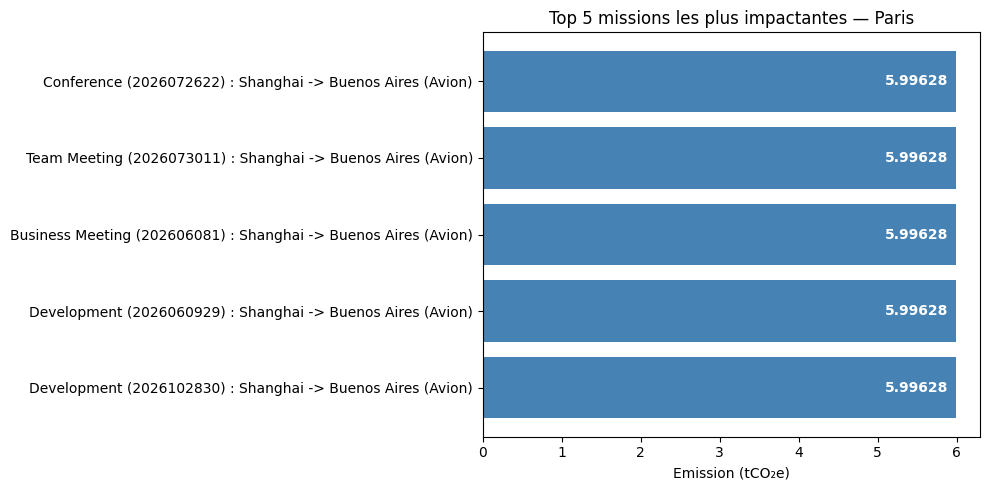

,VILLE_DEPART,VILLE_DESTINATION,TRANSPORT,TYPE_MISSION,ID_DATE_MISSION,EMISSION
1877,Shanghai,Buenos Aires,Avion,Conference,2026-07-26,5.99628
1867,Shanghai,Buenos Aires,Avion,Team Meeting,2026-07-30,5.99628
765,Shanghai,Buenos Aires,Avion,Business Meeting,2026-06-08,5.99628
879,Shanghai,Buenos Aires,Avion,Development,2026-06-09,5.99628
3965,Shanghai,Buenos Aires,Avion,Development,2026-10-28,5.99628


In [ ]:
missions_paris = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter(col("ID_SITE") == "PARIS")
)

missions_paris_df = missions_paris.toPandas()

top5 = missions_paris_df.sort_values("EMISSION", ascending=False).head(5).copy()
top5["ID_MISSION"] = top5["ID_MISSION"].str.replace("Paris_", "")

top5['LABEL'] = top5["TYPE_MISSION"] + " (" + top5["ID_MISSION"] + ") : " + top5['VILLE_DEPART'] + " -> " + top5['VILLE_DESTINATION'] + " (" + top5['TRANSPORT'] + ")"

# Figure
emission_max = top5['EMISSION'].max()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top5['LABEL'][::-1], top5['EMISSION'][::-1], color='steelblue')

for bar, val in zip(bars, top5['EMISSION'][::-1]):
    ax.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va='center', ha='right', color='white', fontweight='bold')

ax.barh(top5['LABEL'][::-1], top5['EMISSION'][::-1], color='steelblue')
ax.set_xlabel("Emission (tCO₂e)")
ax.set_title("Top 5 missions les plus impactantes — Paris")
plt.tight_layout()
plt.savefig("top5_missions_paris.png", dpi=150, bbox_inches='tight')
plt.show()

Question 19 : Proposer une figure comparant l’impact carbone mensuel des missions en fonction du type de transport et sur chaque site.

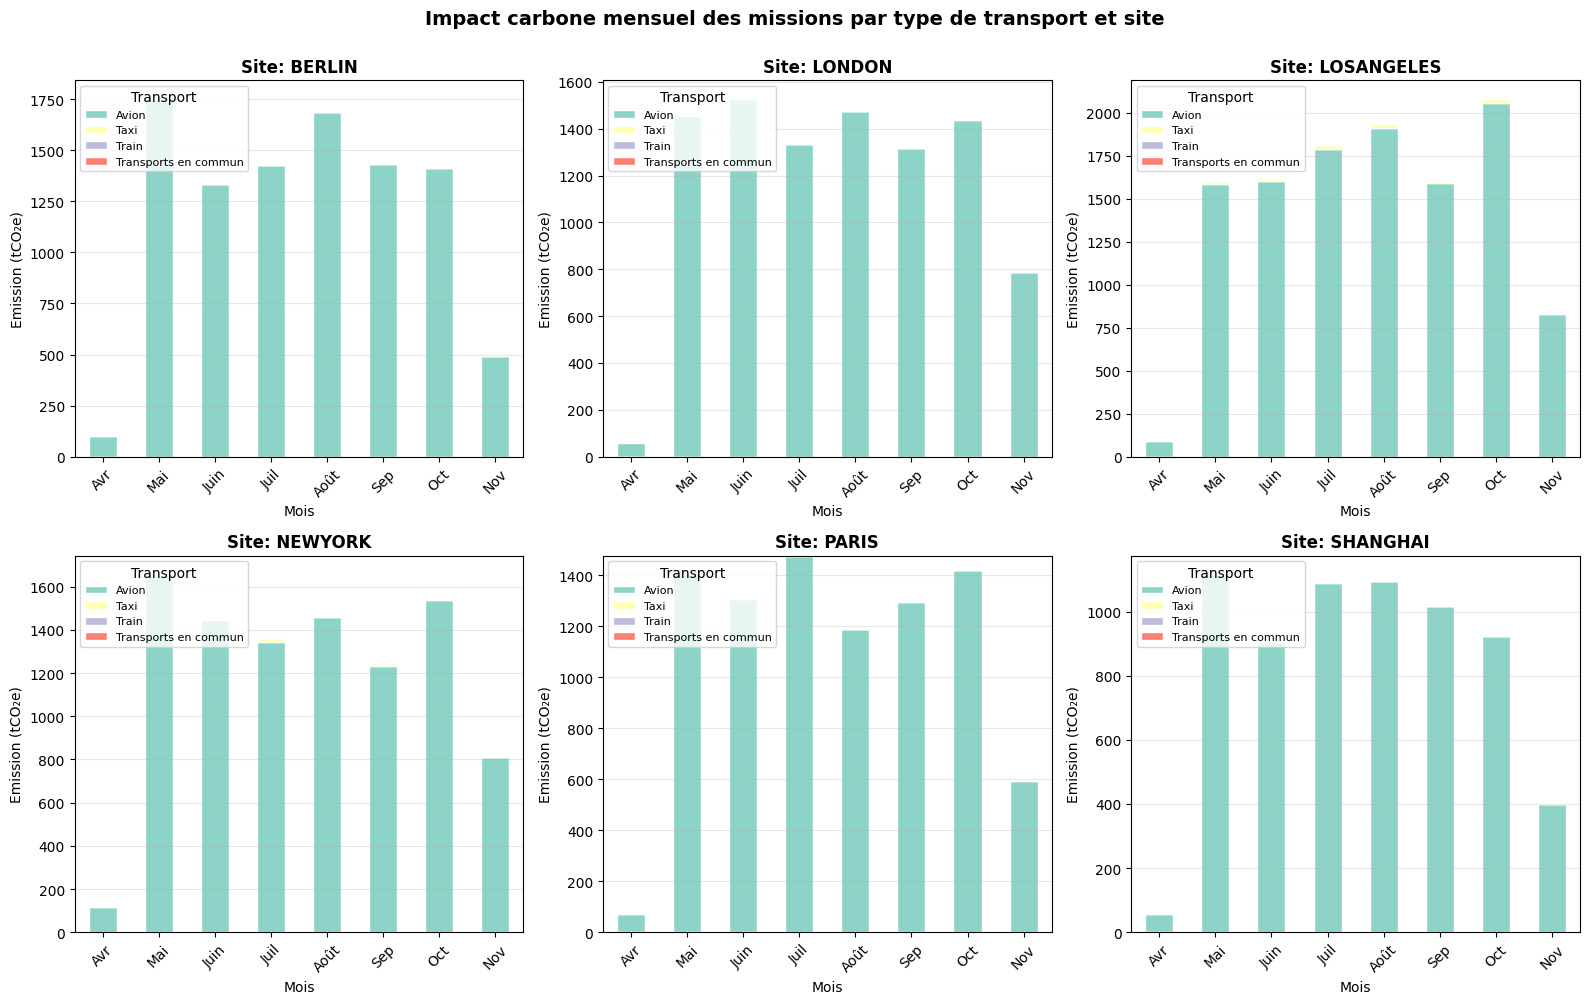

In [ ]:
missions_data = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .select(
        "ID_SITE",
        "VILLE_DEPART",
        "PAYS_DEPART",
        "VILLE_DESTINATION",
        "PAYS_DESTINATION",
        "ALLER_RETOUR",
        "TRANSPORT",
        "ID_DATE_MISSION",
        month("ID_DATE_MISSION").alias("MOIS"),
        "EMISSION"
    )
)

missions_df = missions_data.toPandas()

# Grouper par mois, transport et site
emissions_monthly = missions_df.groupby(['ID_SITE', 'MOIS', 'TRANSPORT'])['EMISSION'].sum().reset_index()

# Créer une figure avec un sous-graphique par site
sites = sorted(emissions_monthly['ID_SITE'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

mois_noms = ['', 'Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
transports_list = sorted(emissions_monthly['TRANSPORT'].unique())
colors = plt.cm.Set3.colors

for idx, site in enumerate(sites):
    ax = axes[idx]
    site_data = emissions_monthly[emissions_monthly['ID_SITE'] == site]
    
    # Pivot pour avoir transports en colonnes
    pivot_data = site_data.pivot(index='MOIS', columns='TRANSPORT', values='EMISSION').fillna(0)
    
    # Créer barres empilées
    pivot_data.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(transports_list)], edgecolor='white')
    
    ax.set_title(f"Site: {site}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Mois")
    ax.set_ylabel("Emission (tCO₂e)")
    ax.set_xticklabels([mois_noms[int(m)] if 1 <= int(m) <= 12 else str(m) for m in pivot_data.index], rotation=45)
    ax.legend(title="Transport", fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Impact carbone mensuel des missions par type de transport et site", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("impact_mensuel_transport_site.png", dpi=150, bbox_inches='tight')
plt.show()

Question 20 : Proposer une figure illustrant l’impact carbone global mensuel de l’organisation.

In [29]:
#Impact carbone mensuel des missions
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .withColumn("MOIS", month("ID_DATE_MISSION"))
    .groupBy(col('MOIS'))
    .agg(sum(col("EMISSION")).alias("EMISSION"))   
    .select("MOIS", "EMISSION")
    .orderBy(col("MOIS").asc())
)

In [30]:
#Impact carbone mensuel du matériel 
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .withColumn("MOIS", month("ID_DATE_ACHAT"))
    .groupBy(col('MOIS'))
    .agg(sum(col("IMPACT")).alias("IMPACT"))   
    .select("MOIS", "IMPACT")
    .orderBy(col("MOIS").asc())
)

In [ ]:
# Calcul de l'impact total
total = (
    missions
    .join(mat_inf, "MOIS")
    .withColumn("TOT_IMPACT", col("EMISSION") + col("IMPACT"))
)

total_df = total.toPandas()
total_df

,MOIS,EMISSION,IMPACT,TOT_IMPACT
0,6,8159.439314,440.374,8599.813314
1,5,8999.747259,465.066,9464.813259
2,9,7922.801065,427.947,8350.748065
3,4,495.246950,26.944,522.190950
4,8,8852.432960,450.522,9302.954960
5,7,8509.839148,470.234,8980.073148
6,10,8832.597926,462.188,9294.785926
7,11,3930.532421,206.170,4136.702421


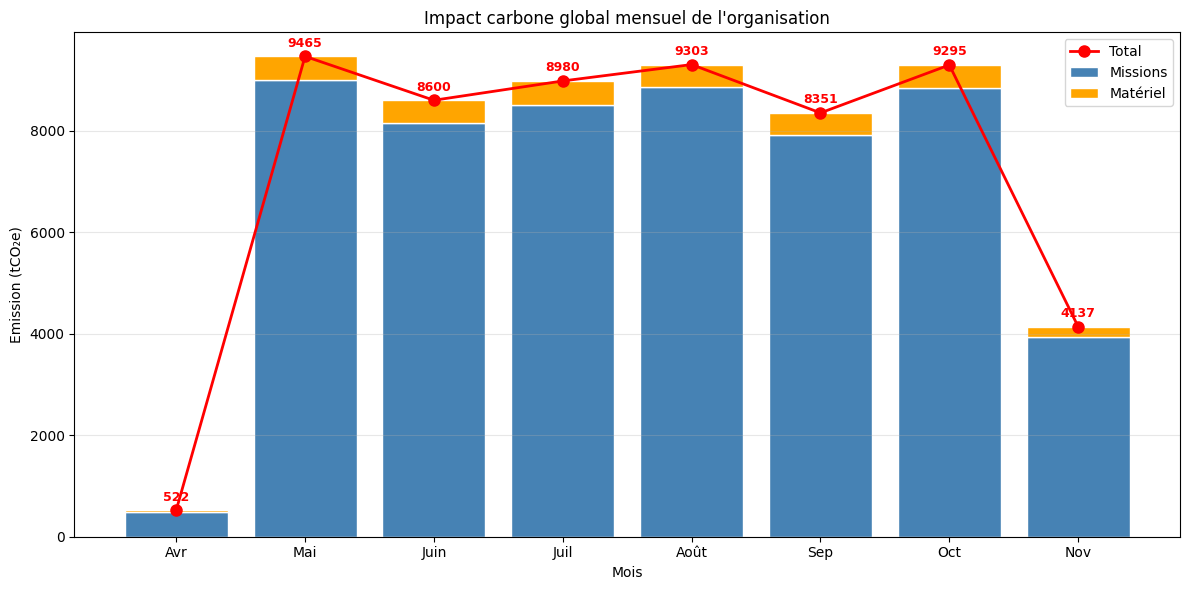

In [33]:
# Tri par mois croissant
df_plot = total_df.sort_values("MOIS").reset_index(drop=True)

# Conversion en noms de mois
mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
df_plot['MOIS_LABEL'] = df_plot['MOIS'].apply(lambda m: mois_noms[m-1])

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_plot))

# Barres empilées : missions + matériel
ax.bar(x, df_plot['EMISSION'], label='Missions', color='steelblue', edgecolor='white')
ax.bar(x, df_plot['IMPACT'], bottom=df_plot['EMISSION'], label='Matériel', color='orange', edgecolor='white')

# Courbe du total
ax.plot(x, df_plot['TOT_IMPACT'], marker='o', color='red', linewidth=2, markersize=8, label='Total', zorder=5)

# Annotations
for i, val in enumerate(df_plot['TOT_IMPACT']):
    ax.text(i, val + df_plot['TOT_IMPACT'].max() * 0.02, f"{val:.0f}",
            ha='center', fontweight='bold', color='red', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['MOIS_LABEL'])
ax.set_xlabel("Mois")
ax.set_ylabel("Emission (tCO₂e)")
ax.set_title("Impact carbone global mensuel de l'organisation")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("impact_global_mensuel.png", dpi=150, bbox_inches='tight')
plt.show()

## Export du modèle étoile pour le Dashboard

Exportation des tables de dimension et de fait en fichiers Parquet pour utilisation par le dashboard Streamlit.

In [ ]:
# Créer le dossier de destination s'il n'existe pas
output_dir = Path("./dashboard_v2/star_model_data")
output_dir.mkdir(parents=True, exist_ok=True)

# Exporter toutes les tables de dimension
dim_personnel.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "dim_personnel"))
dim_mission.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "dim_mission"))
dim_materiel.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "dim_materiel"))
dim_site.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "dim_site"))
dim_date.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "dim_date"))
fait_mission.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "fait_mission"))
fait_materiel.coalesce(1).write.mode("overwrite").parquet(str(output_dir / "fait_materiel"))